In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from lightgbm import LGBMRegressor

pd.set_option('display.max_columns', None)

In [4]:
dt = pd.read_csv('./data/data_clean.csv')
display(dt.info())
display(dt.head())

<class 'pandas.DataFrame'>
RangeIndex: 142299 entries, 0 to 142298
Data columns (total 56 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   first_seen            142299 non-null  str    
 1   days_on_market        142299 non-null  int64  
 2   event_closed          142299 non-null  int64  
 3   mortgage_allowed      142299 non-null  int64  
 4   deal_conditions       142299 non-null  str    
 5   region                142299 non-null  str    
 6   municipality          142299 non-null  str    
 7   district              142299 non-null  str    
 8   lat                   142299 non-null  float64
 9   lon                   142299 non-null  float64
 10  n_metro               142299 non-null  int64  
 11  nearest_metro         142299 non-null  str    
 12  nearest_metro_time    142299 non-null  float64
 13  nearest_metro_walk    142299 non-null  int64  
 14  rooms                 142299 non-null  float64
 15  is_studio  

None

,first_seen,days_on_market,event_closed,mortgage_allowed,deal_conditions,region,municipality,district,lat,lon,n_metro,nearest_metro,nearest_metro_time,nearest_metro_walk,rooms,is_studio,flat_type,total_area,living_area,kitchen_area,floor,total_floors,ceiling_height,renovation,window_view,is_apartments,building_type,parking,is_new_building,seller_type,phone_protected,photos_count,views_total,views_today,price_last,price_points,dist_to_center,price_per_m2,building_age,is_ready,had_discount,price_drop_pct,is_first_floor,is_last_floor,floor_ratio,living_to_total,kitchen_to_total,area_per_room,ppm2_to_district,ppm2_to_municipality,total_lifts,has_lift,bath_separate,bath_combined,balcony_count,loggia_count
0,2026-04-07 00:17:49.545645+00:00,3801,1,0,alternative,Москва,САО,Беговой,55.781467,37.561070,3,Беговая,13.0,0,3.0,0,unknown,73.8,45.3,8.8,3,14,2.80,cosmetic,yardAndStreet,0,brick,unknown,0,specialist,0,NaN,NaN,NaN,26000000,1,4.816265,352303.523035,56,True,0,0.000000,0,0,0.214286,0.613821,0.119241,24.600000,0.652084,0.889634,0.0,0,1,0,0,2
1,2026-04-06 21:40:26.848342+00:00,3766,1,0,alternative,Московская область,Реутов,unknown,55.763790,37.858013,3,Новогиреево,13.0,0,3.0,0,unknown,90.1,64.0,9.1,4,4,2.65,cosmetic,unknown,0,unknown,unknown,0,agency,0,NaN,NaN,NaN,16490000,1,15.105500,183018.867925,64,True,0,0.000000,0,1,1.000000,0.710322,0.100999,30.033333,0.851038,0.774286,0.0,0,1,0,2,0
2,2026-04-07 00:14:06.924608+00:00,3520,1,1,free,Москва,Красная Пахра село,unknown,55.431595,37.271490,3,Потапово,24.0,0,3.0,0,rooms,92.0,52.0,15.0,4,6,3.00,euro,yardAndStreet,0,brick,ground,0,specialist,1,NaN,167.0,NaN,22000000,1,41.737163,239130.434783,19,True,0,0.000000,0,0,0.666667,0.565217,0.163043,30.666667,1.111957,0.993272,0.0,0,1,1,0,1
3,2026-04-10 15:36:16.683205+00:00,3554,1,1,free,Московская область,Красногорск,unknown,55.813618,37.311794,3,Красногорская,8.0,1,2.0,0,rooms,48.0,36.0,7.5,2,5,2.80,euro,unknown,0,panel,ground,0,specialist,1,NaN,1476.0,1.0,10500000,1,20.306127,218750.000000,56,True,0,0.000000,0,0,0.400000,0.750000,0.156250,24.000000,0.967601,0.804735,0.0,0,0,1,1,0
4,2026-04-06 23:59:38.314351+00:00,3434,1,1,free,Московская область,Истра муниципальный округ,unknown,55.863490,37.045868,1,Нахабино,20.0,0,1.0,0,rooms,43.9,12.0,13.0,9,15,2.80,cosmetic,unknown,0,monolith,ground,0,specialist,1,NaN,1623.0,NaN,6950000,3,37.810351,158314.350797,13,True,0,-0.037313,0,0,0.600000,0.273349,0.296128,43.900000,0.633257,0.814553,2.0,1,0,1,0,1


In [5]:
# приведение типов
dt['first_seen'] = pd.to_datetime(dt['first_seen'],format='ISO8601')
dt[['rooms','total_lifts','photos_count','views_total','views_today']] = dt[['rooms','total_lifts','photos_count','views_total','views_today']].astype('Int64')
dt[['event_closed','mortgage_allowed','nearest_metro_walk','is_studio','is_apartments','is_new_building',
    'phone_protected','had_discount','is_first_floor','is_last_floor','has_lift']] = dt[['event_closed','mortgage_allowed','nearest_metro_walk','is_studio','is_apartments','is_new_building',
                                                                                         'phone_protected','had_discount','is_first_floor','is_last_floor','has_lift']].astype('bool')

In [6]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 142299 entries, 0 to 142298
Data columns (total 56 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   first_seen            142299 non-null  datetime64[us, UTC]
 1   days_on_market        142299 non-null  int64              
 2   event_closed          142299 non-null  bool               
 3   mortgage_allowed      142299 non-null  bool               
 4   deal_conditions       142299 non-null  str                
 5   region                142299 non-null  str                
 6   municipality          142299 non-null  str                
 7   district              142299 non-null  str                
 8   lat                   142299 non-null  float64            
 9   lon                   142299 non-null  float64            
 10  n_metro               142299 non-null  int64              
 11  nearest_metro         142299 non-null  str                
 12 

In [7]:
dt.isna().sum().sort_values(ascending = False)

# пропусков нет нигде, кроме трех полей:
# views_today             93910
# photos_count            92739
# views_total              2243

views_today             118157
photos_count            107052
views_total               4484
first_seen                   0
deal_conditions              0
days_on_market               0
event_closed                 0
mortgage_allowed             0
lat                          0
lon                          0
n_metro                      0
nearest_metro                0
nearest_metro_time           0
nearest_metro_walk           0
rooms                        0
is_studio                    0
flat_type                    0
total_area                   0
living_area                  0
kitchen_area                 0
floor                        0
region                       0
municipality                 0
district                     0
renovation                   0
ceiling_height               0
total_floors                 0
window_view                  0
parking                      0
is_new_building              0
building_type                0
is_apartments                0
phone_pr

In [8]:
(dt == 'unknown').sum().sort_values(ascending = False)

# unknown значительно больше, чем пропусков, особенно беспокоит 95% по district

renovation              81454
district                76806
window_view             68581
parking                 62324
municipality            45001
building_type           22216
nearest_metro            7343
flat_type                  93
deal_conditions             0
region                      0
event_closed                0
lat                         0
nearest_metro_time          0
nearest_metro_walk          0
lon                         0
n_metro                     0
is_studio                   0
rooms                       0
living_area                 0
total_area                  0
kitchen_area                0
mortgage_allowed            0
first_seen                  0
days_on_market              0
ceiling_height              0
total_floors                0
floor                       0
is_apartments               0
is_new_building             0
seller_type                 0
phone_protected             0
photos_count                0
views_total                 0
views_toda

In [9]:
dt.describe()

# обратить внимание:
# rooms = 0 (min)
# floor = -2 (min)
# ceiling_height = 0 (min), 3250 (max)
# views_total = 536340 (max)
# dist_to_center = 2811.959345 (max)
# building_age = -3 (min), 934 (max)
# floor_ratio = -0.4 (min)
# total_lifts = 43 (max)

,days_on_market,lat,lon,n_metro,nearest_metro_time,rooms,total_area,living_area,kitchen_area,floor,total_floors,ceiling_height,photos_count,views_total,views_today,price_last,price_points,dist_to_center,price_per_m2,building_age,price_drop_pct,floor_ratio,living_to_total,kitchen_to_total,area_per_room,ppm2_to_district,ppm2_to_municipality,total_lifts,bath_separate,bath_combined,balcony_count,loggia_count
count,142299.000000,142299.000000,142299.000000,142299.000000,142299.000000,142299.0,142299.000000,142299.000000,142299.000000,142299.000000,142299.000000,142299.000000,35247.0,137815.0,24142.0,1.422990e+05,142299.000000,142299.000000,1.422990e+05,142299.000000,142299.000000,142299.000000,142299.000000,142299.000000,142299.000000,142299.000000,142299.000000,142299.0,142299.000000,142299.00000,142299.000000,142299.000000
mean,84.321373,55.729698,37.575497,3.068019,13.406124,1.887497,55.162244,28.526624,12.889672,10.506989,19.495984,2.837905,16.978807,554.200711,5.045481,1.985392e+07,3.519181,21.341201,3.552959e+05,16.101729,-0.009297,0.554956,0.506954,0.247582,31.327176,1.043392,1.042983,2.624221,-0.003767,0.32086,-0.415801,-0.393144
std,156.047291,0.221950,0.451554,1.064210,6.158037,0.86938,19.178202,12.932282,5.113051,8.752263,11.968663,0.259392,9.79922,1882.209573,11.329895,1.324647e+07,5.179810,30.758836,1.671567e+05,19.268069,0.080002,0.286401,0.116104,0.098658,7.980557,0.307805,0.292134,3.882455,0.793771,1.00692,0.838620,0.868078
min,0.000000,44.483532,29.961061,0.000000,1.000000,0.0,24.300000,9.200000,4.000000,-2.000000,1.000000,2.000000,1.0,1.0,1.0,4.400000e+06,1.000000,0.429728,1.014925e+05,-3.000000,-5.000000,-0.666667,0.095951,0.041007,0.722222,0.151682,0.165965,0.0,-1.000000,-1.00000,-1.000000,-1.000000
25%,14.000000,55.627590,37.428160,3.000000,8.000000,1.0,39.400000,18.000000,9.200000,4.000000,12.000000,2.700000,10.0,19.0,1.0,1.090000e+07,1.000000,11.636802,2.254011e+05,6.000000,-0.008551,0.302326,0.422185,0.172911,25.350000,0.844455,0.858837,0.0,-1.000000,-1.00000,-1.000000,-1.000000
50%,36.000000,55.720400,37.549023,3.000000,13.000000,2.0,51.900000,27.100000,12.000000,8.000000,17.000000,2.800000,15.0,136.0,2.0,1.640057e+07,2.000000,19.341943,3.253062e+05,7.000000,0.000000,0.560000,0.512465,0.232558,30.500000,1.000000,1.000000,2.0,0.000000,1.00000,-1.000000,-1.000000
75%,93.000000,55.833282,37.737400,3.000000,18.000000,2.0,66.100000,36.300000,16.000000,15.000000,24.000000,2.950000,21.0,599.0,4.0,2.404350e+07,4.000000,25.435874,4.444519e+05,14.000000,0.000000,0.800000,0.588235,0.316241,36.700000,1.184159,1.175859,3.0,1.000000,1.00000,0.000000,0.000000
max,3801.000000,60.117370,82.961240,15.000000,60.000000,36.0,137.300000,73.000000,33.000000,76.000000,95.000000,7.900000,50.0,536340.0,484.0,1.250000e+08,147.000000,2811.650174,1.004673e+06,241.000000,0.900000,1.000000,1.000000,1.000000,135.900000,4.650000,5.009040,43.0,9.000000,9.00000,4.000000,4.000000


In [10]:
for col in dt.select_dtypes(include='str').columns:
    print()
    print(col, dt[col].nunique())
    print(dt[col].value_counts().head(10))

# investment,dzhsk,свободная продажа -> alternative
# отфильтровать регионы - Москва и МО
# проверить district
# привести bathrooms?
# привести balcony?
# window_view -> на сколько сторон окна: yardAndStreet = 2, yard = 1, street = 1
# привести building_type


deal_conditions 8
deal_conditions
fz214                66304
free                 63808
alternative           9223
dupt                  2618
pdkp                   300
investment              35
dzhsk                    9
свободная продажа        2
Name: count, dtype: int64

region 6
region
Москва                   83533
Московская область       58666
Санкт-Петербург             80
Крым респ.                  12
Новосибирская область        7
Челябинская область          1
Name: count, dtype: int64

municipality 214
municipality
unknown                        45001
НАО (Новомосковский)            8546
Ленинский городской округ       6126
Мытищи                          5173
ЮВАО                            4582
Балашиха                        3927
САО                             3726
Красногорск городской округ     3705
Одинцовский городской округ     3446
ЮАО                             3426
Name: count, dtype: int64

district 175
district
unknown                 76806
Даниловский   

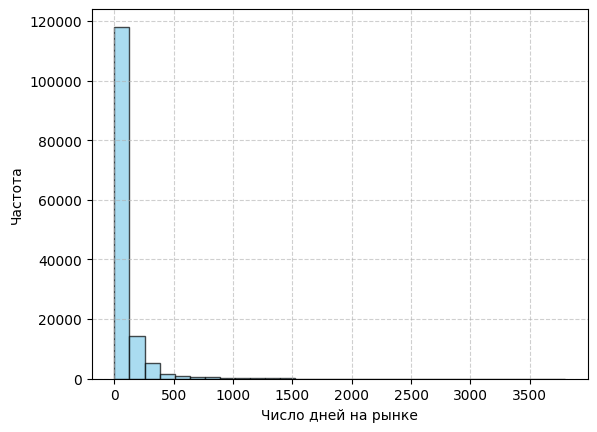

In [11]:
plt.hist(dt['days_on_market'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.xlabel('Число дней на рынке')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [12]:
# ИЗМЕНЕНИЯ В ДАТАСЕТЕ

# удаляем views_today и photos_count - счетные признаки, более 80% пропусков, малая содержательная нагрузка + views_total
dt = dt.drop(columns=['views_today','photos_count'])

# фильтруем только объявления в Москве и МО. Это должно также убрать выбросы по dist_to_center, lat, lon
dt = dt[dt['region'].isin(['Москва','Московская область'])]

# rooms = 0 (min) - вероятно, свободная планировка - оставим пока
# floor = -2 (min) - сомнительно, но окэй х)

# views_total = 536340 - такой выброс всего один, следующее максимальное значение 58733, скорее всего ошибка. Присвоим ему NaN.
dt.loc[dt['views_total']>100000, 'views_total'] = np.nan

# ceiling_height - возьмем от 2 метров до 8 метров (пентхаус), остальные скорее всего ошибка
dt = dt[dt['ceiling_height'].between(2, 8)]

# building_age = -3 (min), 934 (max) - верхнее значение точно ошибка, это Подольск, ему еще нет столько лет.
# А нижние (отрицательные) значения - если это в строящихся домах, то почему маркер is_ready у всех true? Надо разобраться.
dt = dt[dt['building_age']<300]

# floor_ratio = -0.4 (min) - от подземных этажей, вероятно

# days_on_market - срезаем хвосты по 1 и 99 перцентилю (снизу мгновенные репосты, сверху "продается 10+ лет")
dom_low, dom_high = dt['days_on_market'].quantile([0.01, 0.99])
dt = dt[dt['days_on_market'].between(dom_low, dom_high)]

In [ ]:
# зависимости для цены за кв.м. и переменных с наибольшей корреляцией

pairs = [
    ('n_metro', 'price_per_m2'),
    ('total_floors', 'price_per_m2'),
    ('floor', 'price_per_m2')
]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(data=dt, x=x_col, y=y_col, alpha=0.3, s=10, ax=ax)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs {x_col}')

plt.suptitle('Зависимость цены за кв.м. от ключевых факторов', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# зависимости для срока продажи и переменных с наибольшей корреляцией

pairs = [
    ('living_area', 'days_on_market'),
    ('views_total', 'days_on_market'),
    ('price_points', 'days_on_market')
]

fig, axes = plt.subplots(1, len(pairs), figsize=(16, 5))

for ax, (x_col, y_col) in zip(axes, pairs):
    sns.scatterplot(data=dt, x=x_col, y=y_col, alpha=0.3, s=10, ax=ax)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} vs {x_col}')

plt.suptitle('Зависимость срока продажи от ключевых факторов', y=1.02)
plt.tight_layout()
plt.show()

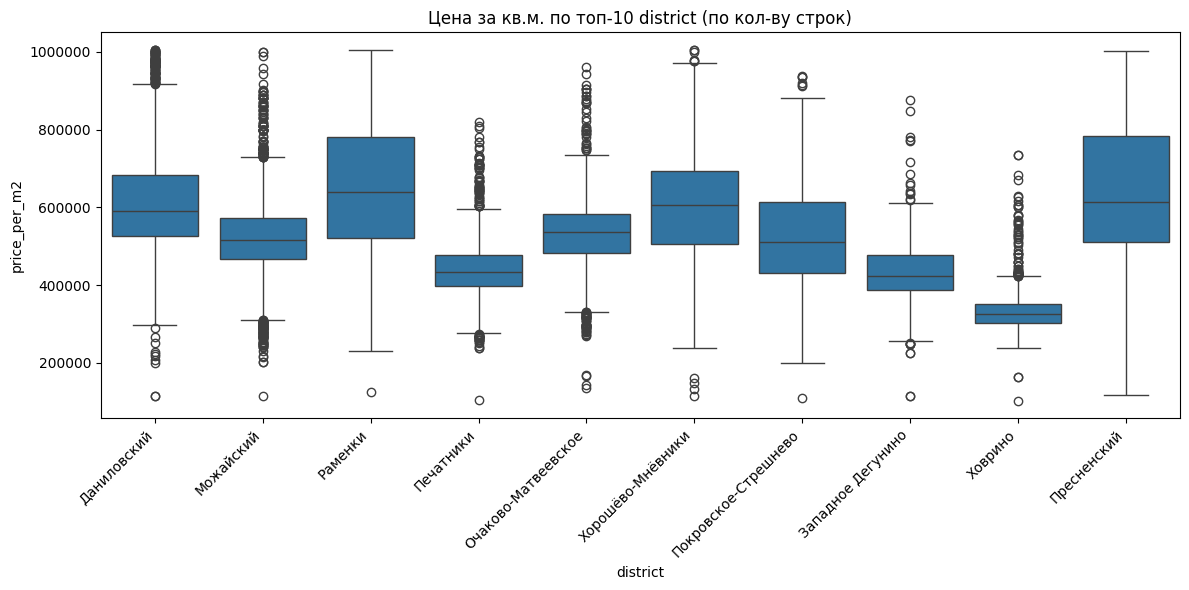

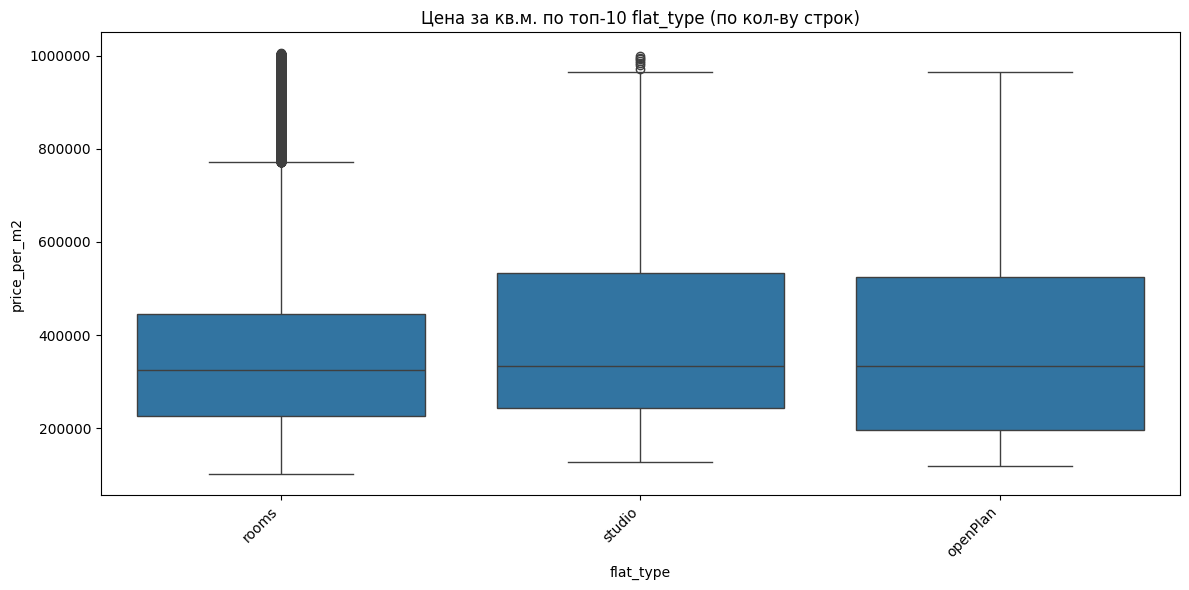

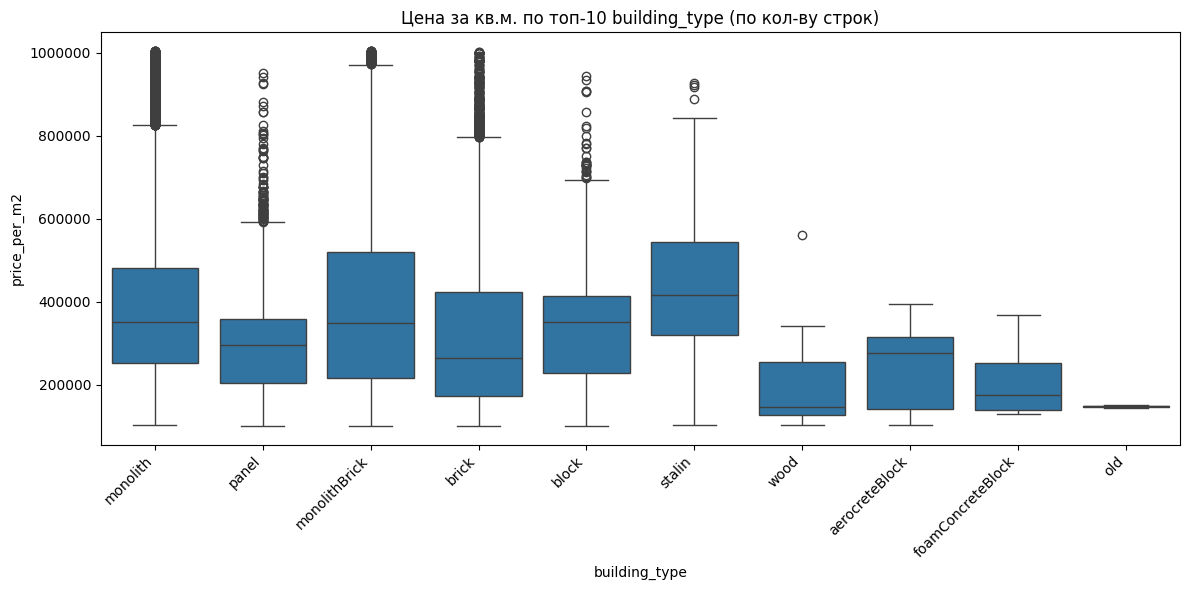

In [15]:
cols_to_plot = ['district', 'flat_type', 'building_type']

for col in cols_to_plot:
    dt_clean = dt[dt[col].ne('unknown') & dt[col].notna()]
    top_cats = dt_clean[col].value_counts().head(10).index
    dt_top = dt_clean[dt_clean[col].isin(top_cats)]
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=dt_top, x=col, y='price_per_m2', order=top_cats)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Цена за кв.м. по топ-10 {col} (по кол-ву строк)')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()


### Распределение таргета (days_on_market) по категориальным признакам

In [16]:
def target_by_category(frame, col, target='days_on_market', min_count=200):
    g = frame.groupby(col)[target]
    table = g.agg(
        n='count',
        p10=lambda s: s.quantile(0.10),
        p25=lambda s: s.quantile(0.25),
        p50='median',
        p75=lambda s: s.quantile(0.75),
        p90=lambda s: s.quantile(0.90),
    )
    return table[table['n'] >= min_count].sort_values('p50').round(1)

cat_features = ['region', 'seller_type', 'rooms', 'is_new_building', 'is_apartments',
                'deal_conditions', 'building_type', 'renovation', 'parking', 'flat_type',
                'has_lift', 'mortgage_allowed', 'nearest_metro_walk']

for col in cat_features:
    print(col)
    display(target_by_category(dt, col))

region


,n,p10,p25,p50,p75,p90
region,,,,,,
Москва,82808,5.0,12.0,30.0,88.0,181.0
Московская область,57970,5.0,17.0,42.0,93.0,175.1


seller_type


,n,p10,p25,p50,p75,p90
seller_type,,,,,,
specialist,44689,6.0,16.0,29.0,71.0,150.0
agency,95986,5.0,12.0,38.0,95.0,190.0


rooms


...

,n,p10,p25,p50,p75,p90
has_lift,,,,,,
True,103555,5.0,13.0,34.0,88.0,181.0
False,37223,6.0,16.0,38.0,93.0,173.0


mortgage_allowed


,n,p10,p25,p50,p75,p90
mortgage_allowed,,,,,,
True,107944,5.0,14.0,34.0,88.0,183.0
False,32834,6.0,14.0,38.0,101.0,162.0


nearest_metro_walk


,n,p10,p25,p50,p75,p90
nearest_metro_walk,,,,,,
True,77206,5.0,13.0,31.0,89.0,181.0
False,63572,5.0,15.0,38.0,92.0,176.0


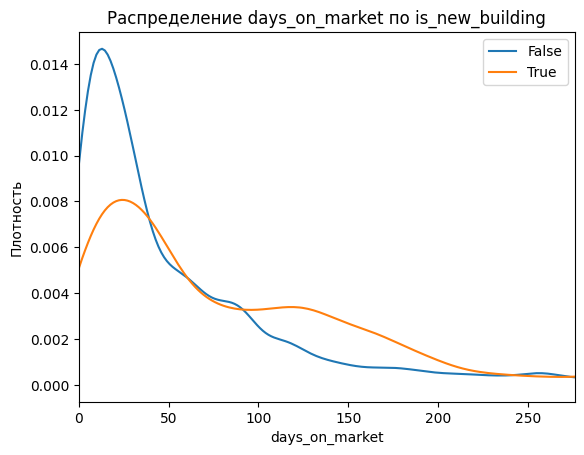

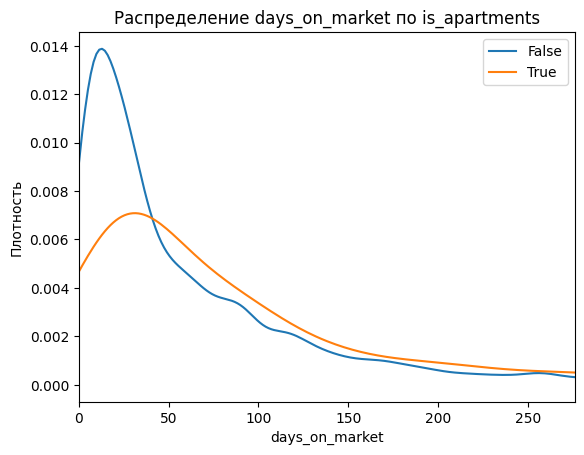

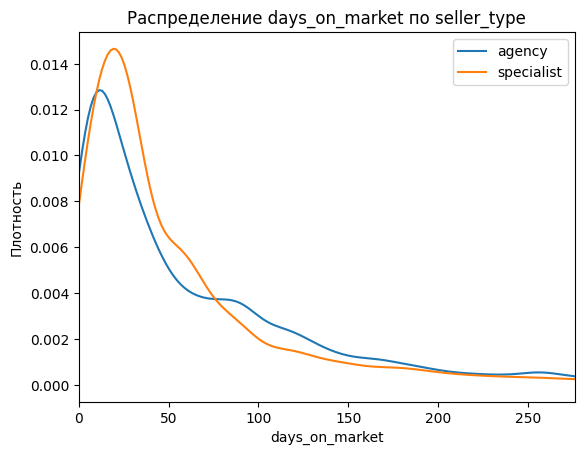

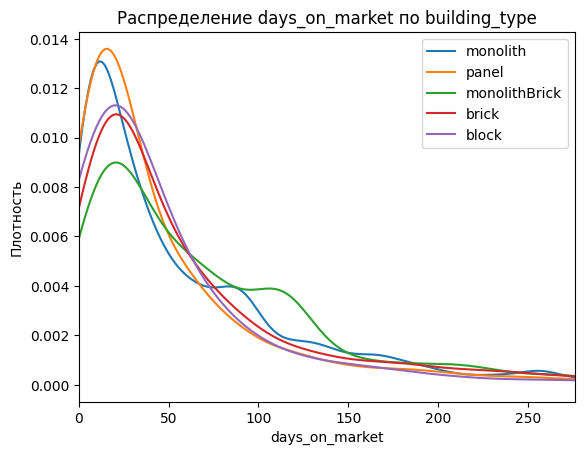

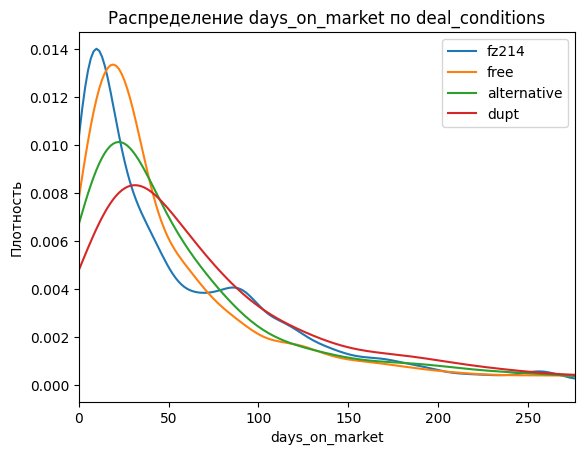

In [17]:
overlay_features = ['is_new_building', 'is_apartments', 'seller_type', 'building_type', 'deal_conditions']
clip = dt['days_on_market'].quantile(0.95)

for col in overlay_features:
    counts = dt[dt[col].ne('unknown')][col].value_counts()
    cats = counts[counts >= 500].index
    plt.figure()
    for val in cats:
        dt.loc[dt[col] == val, 'days_on_market'].plot(kind='kde', label=str(val))
    plt.title(f'Распределение days_on_market по {col}')
    plt.xlabel('days_on_market')
    plt.ylabel('Плотность')
    plt.xlim(0, clip)
    plt.legend()
    plt.show()

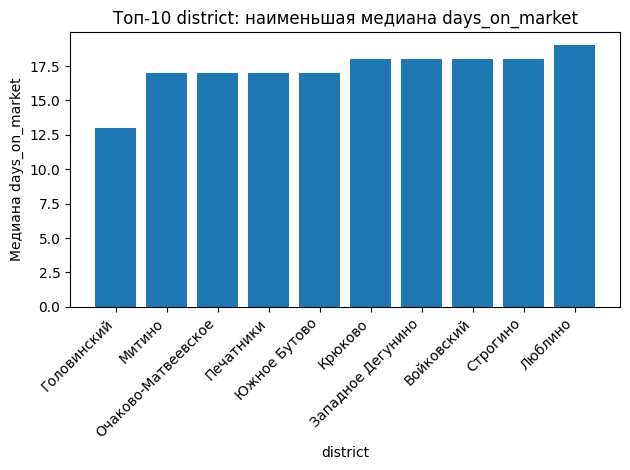

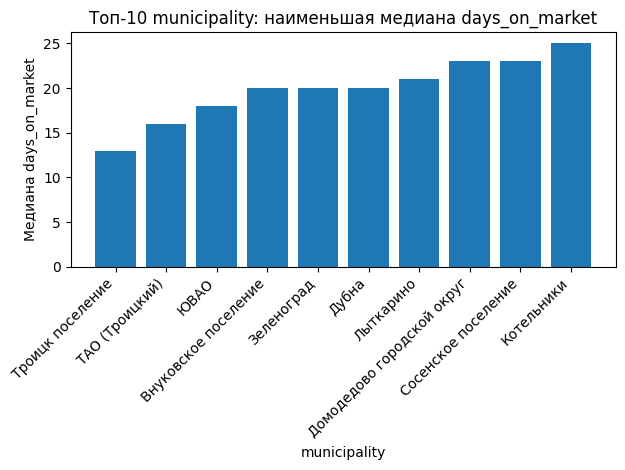

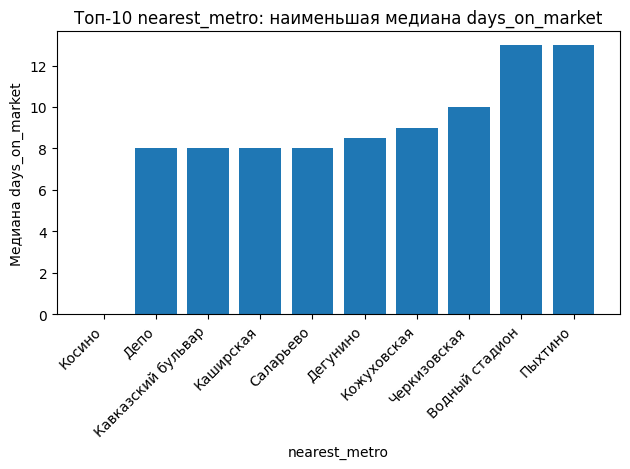

In [18]:
def lowest_median_bar(frame, col, target='days_on_market', top=10, min_count=100):
    sub = frame[frame[col].ne('unknown')]
    stats = sub.groupby(col)[target].agg(['median', 'count'])
    stats = stats[stats['count'] >= min_count].sort_values('median').head(top)
    plt.figure()
    plt.bar(stats.index, stats['median'])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Топ-{top} {col}: наименьшая медиана days_on_market')
    plt.xlabel(col)
    plt.ylabel('Медиана days_on_market')
    plt.tight_layout()
    plt.show()

for col in ['district', 'municipality', 'nearest_metro']:
    lowest_median_bar(dt, col)

### Анализ важности признаков

c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable event_closed for analysis 1. Dropping this column
  warnings.warn(


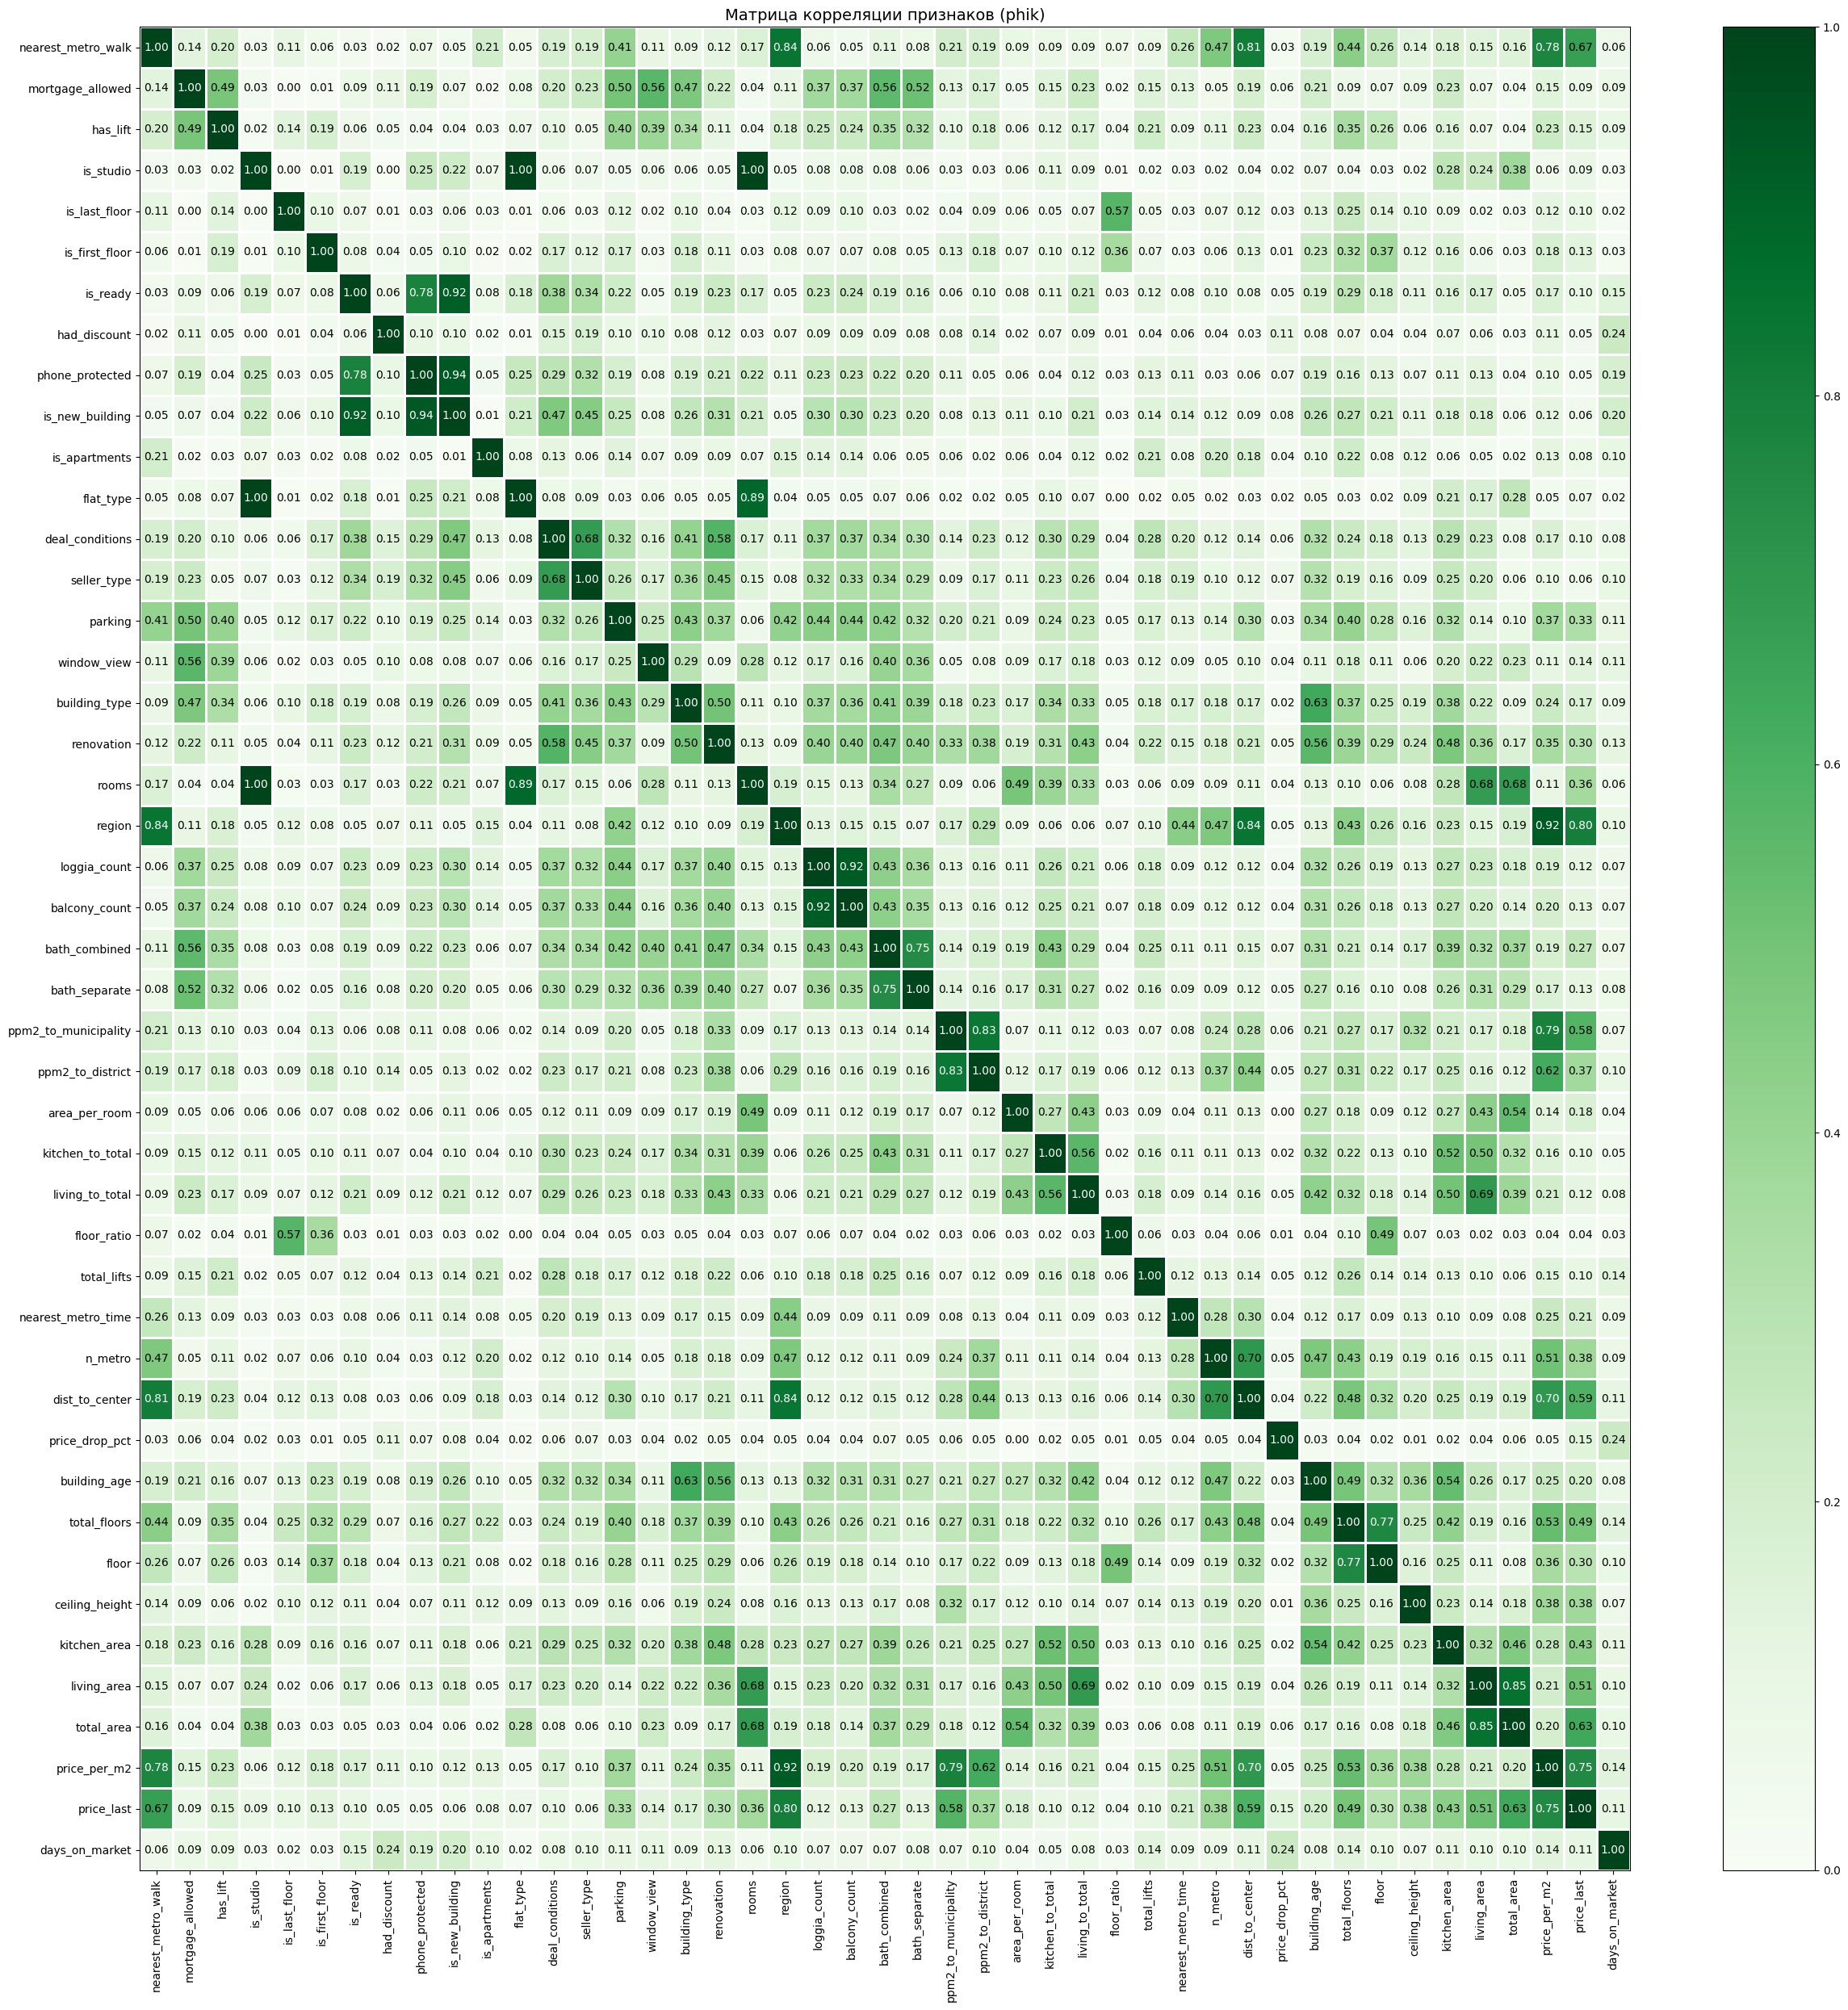

In [19]:


interval_cols = [
    'days_on_market', 'price_last', 'price_per_m2', 'total_area', 'living_area',
    'kitchen_area', 'ceiling_height', 'floor', 'total_floors', 'building_age',
    'price_drop_pct', 'dist_to_center', 'n_metro', 'nearest_metro_time', 'total_lifts',
    'floor_ratio', 'living_to_total', 'kitchen_to_total', 'area_per_room',
    'ppm2_to_district', 'ppm2_to_municipality',
    'bath_separate', 'bath_combined', 'balcony_count', 'loggia_count',
]
phik_cols = interval_cols + [
    'region', 'rooms', 'renovation', 'building_type', 'window_view',
    'parking', 'seller_type', 'deal_conditions', 'flat_type', 'is_apartments', 'is_new_building',
    'phone_protected', 'had_discount', 'is_ready', 'event_closed',
    'is_first_floor', 'is_last_floor', 'is_studio', 'has_lift', 'mortgage_allowed', 'nearest_metro_walk',
]

phik_df = dt[phik_cols].copy()
phik_df[interval_cols] = phik_df[interval_cols].astype('float64')
for col in phik_cols:
    if str(phik_df[col].dtype) in ('boolean', 'bool', 'Int64'):
        phik_df[col] = phik_df[col].astype('int64').astype('object')

phik_matrix = phik_df.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1, color_map='Greens',
    title='Матрица корреляции признаков (phik)',
    fontsize_factor=1,
    figsize=(25, 25)
)
plt.tight_layout()
plt.show()

### Бейзлайн и анализ важности признаков

In [20]:
leak_cols = ['days_on_market', 'first_seen', 'event_closed', 'price_points',
             'views_total', 'views_today', 'photos_count', 'had_discount', 'price_drop_pct']

y = dt['days_on_market'].astype(float)
X = dt.drop(columns=[c for c in leak_cols if c in dt.columns])

cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype('category')

X.shape, len(cat_cols)

((140778, 47), 11)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=93,
    subsample=1,
    colsample_bytree=1,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train, categorical_feature=cat_cols)

pred = model.predict(X_test)
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
print('R2:', round(r2, 4))
print('MAE (дней):', round(mae, 1))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4794
[LightGBM] [Info] Number of data points in the train set: 112622, number of used features: 47
[LightGBM] [Info] Start training from score 73.092034
R2: 0.3379
MAE (дней): 46.6


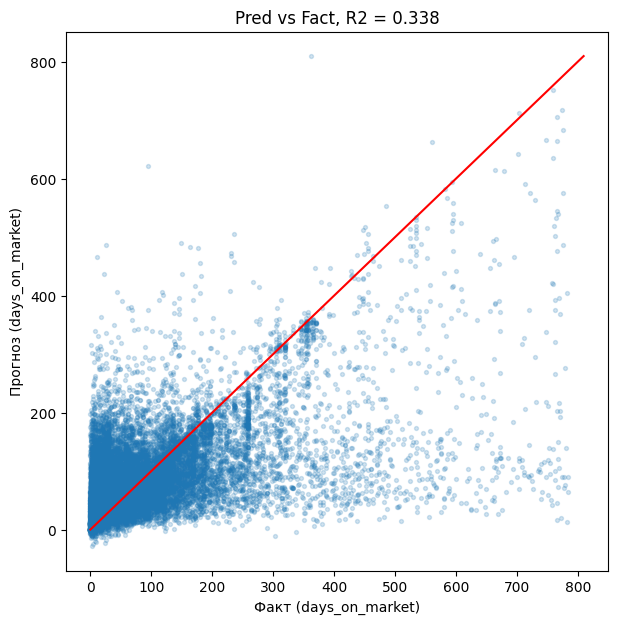

In [22]:
lim = max(y_test.max(), pred.max())

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.2, s=8)
plt.plot([0, lim], [0, lim], color='red')
plt.xlabel('Факт (days_on_market)')
plt.ylabel('Прогноз (days_on_market)')
plt.title(f'Pred vs Fact, R2 = {round(r2, 3)}')
plt.show()

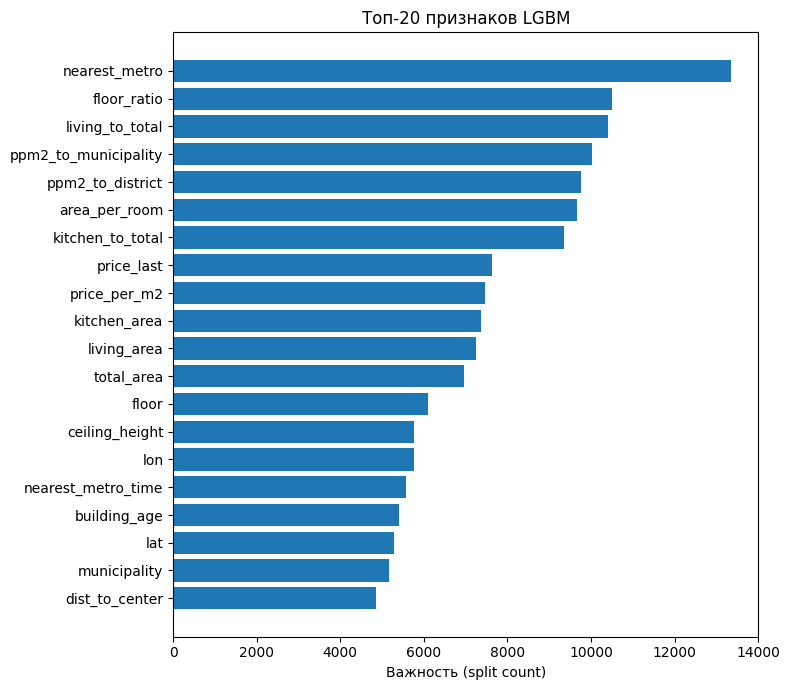

In [23]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(20)

plt.figure(figsize=(8, 7))
plt.barh(importance.index, importance.values)
plt.xlabel('Важность (split count)')
plt.title('Топ-20 признаков LGBM')
plt.tight_layout()
plt.show()

### Финальный экспорт датасета

In [ ]:
final = dt.copy()
bool_cols = final.select_dtypes(include='bool').columns
final[bool_cols] = final[bool_cols].astype('int8')
final.to_csv('./data/data_final.csv', index=False)
final.shape

(140778, 54)

: 